# RollerCoasterContAcceleration


The program computes the motion of a roller coaster in a
continuous elastic band model. The accelerations acting
on a passenger are calculated.

## Gaussian mountain profile

$$ h(x) = H e^{-a^2 x^2} $$

$$ h'(x) = -2 a^2 x H e^{-a^2 x^2} $$

$$ h''(x) = 2 a^2 (2 a^2 x^2 - 1) H e^{-a^2 x^2} $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions


In [2]:
def gauss(x, a, H):
    zg = H * np.exp(-a**2 * x**2)
    return zg

def hp(x, a, H):
    hprime = -2 * a**2 * x * gauss(x, a, H)
    return hprime

def h2p(x, a, H):
    h2prime = 2 * a**2 * (2 * a**2 * x**2 - 1) * gauss(x, a, H)
    return h2prime

## Parameters

In [3]:
H = 8                           # Mountain height
B = 10                          # Mountain width
a = np.sqrt(np.log(2)) / B      # Gaussian parameter
g = 9.81                        # Gravitational acceleration

L = 10.0                        # Train length in m
rho = 500                       # Mass density per unit length (kg/m)
Phi = 200000                    # Elastic modulus per unit length

NG = 1001                       # Material grid points
dl = L / (NG - 1)               # Distance between material grid points
l = np.linspace(0, L, NG)

Tmax = 8 * np.sqrt(2 * H / g)   # Maximum time
NT = 100001                     # Time steps
dt = Tmax / (NT - 1)            # Time step size
t = np.linspace(0, Tmax, NT)    # Time grid

C = Phi / rho * (dt / dl)**2

## Prepare grid

In [4]:
# Positions of the train
x = np.zeros((NT, NG))

# Accelerations of passengers in x-direction
apx = np.zeros((NT, NG))

# Accelerations in z-direction
apz = np.zeros((NT, NG))

# Normal components
apn = np.zeros((NT, NG))

## Initial condition

$$ x_i(0) = l_i - \frac{4}{a} $$

Second time step necessary for second order ODE.

$$ v = \sqrt{\frac{2 g (H - h(x))}{1 + (h'(x))^2}} $$

In [5]:
# Train is relaxed
x[0, :] = l - 4/a

dhdx0 = hp(x[0, :], a, H)

x[1, :] = x[0, :] + 0.98 * np.sqrt(
    2 * g * (H - gauss(x[0, :], a, H)) / (1 + dhdx0**2)
) * dt

## Finite difference method

$$ x_i^{n+1} = 2x_i^n - x_i^{n-1} - c (\Delta_t x)^2 - g b \Delta t^2 + C (c (\Delta_l x)^2 + \Delta_l^2 x) $$

Passenger accelerations:

$$ a_n = \frac{h'' \dot{x}^2 - g}{\sqrt{1+(h')^2}} $$

$$ a_x = -c \dot{x}^2 $$

$$ a_z = -\frac{a_x}{h'} - g $$

In [6]:
for j in range(2, NT):

    x_prev = x[j-1]
    x_prev2 = x[j-2]

    dhdx = hp(x_prev[1:-1], a, H)
    d2hdx2 = h2p(x_prev[1:-1], a, H)

    b = dhdx / (1 + dhdx**2)
    c = d2hdx2 * b

    dxdt = x_prev[1:-1] - x_prev2[1:-1]
    dxdl = x_prev[1:-1] - x_prev[:-2]
    d2xdl2 = x_prev[2:] + x_prev[:-2] - 2 * x_prev[1:-1]

    x[j, 1:-1] = (
        2 * x_prev[1:-1] - x_prev2[1:-1]
        - c * dxdt**2
        - g * b * dt**2
        + C * (c * dxdl**2 + d2xdl2)
    )

    velocity = dxdt / dt

    apn[j, 1:-1] = (d2hdx2 * velocity**2 - g) / np.sqrt(1 + dhdx**2)
    apx[j, 1:-1] = -c * velocity**2
    apz[j, 1:-1] = -apx[j, 1:-1] / dhdx - g

    # Beginning and end move along and are set relative to
    # neighboring points with distance dl
    x[j, 0] = x[j, 1] - dl
    x[j, -1] = x[j, -2] + dl

## Visualization

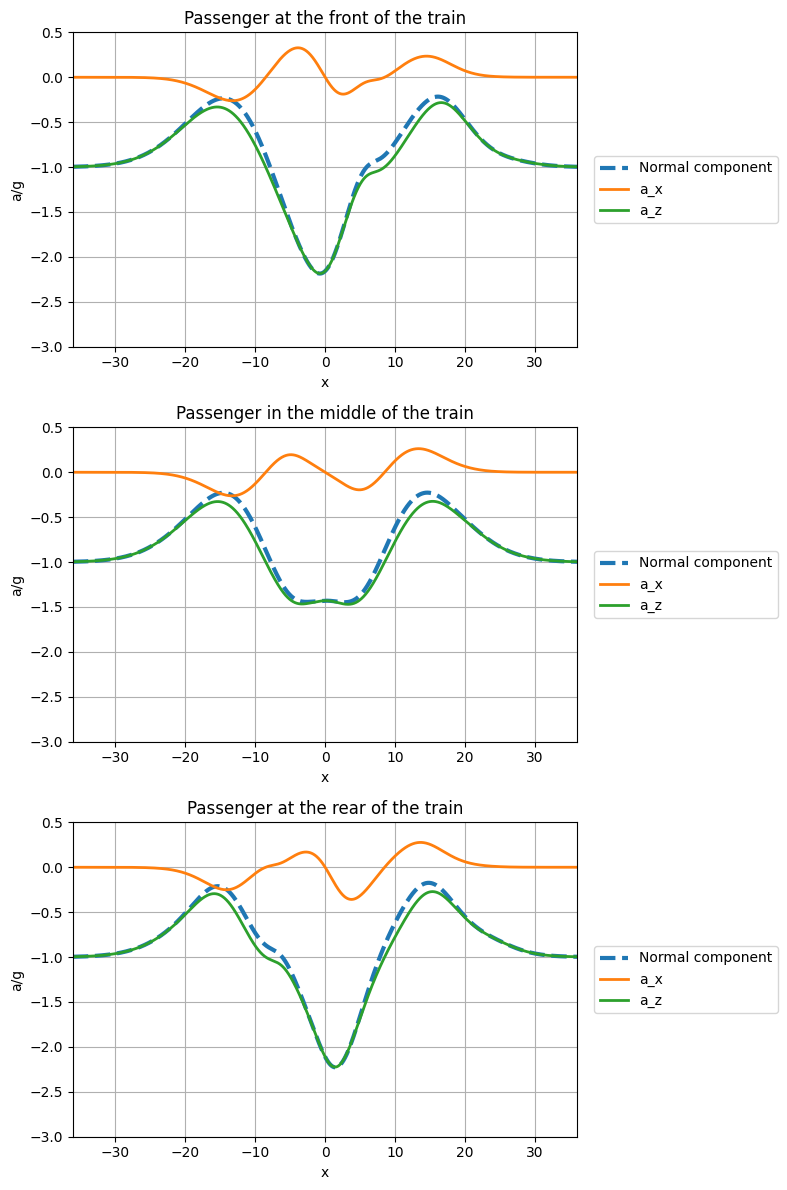

In [7]:
plt.figure(figsize=(8, 12))

indices = [998, 500, 2]
titles = [
    "Passenger at the front of the train",
    "Passenger in the middle of the train",
    "Passenger at the rear of the train"
]

for k in range(3):
    plt.subplot(3, 1, k+1)
    idx = indices[k]

    plt.plot(x[:, idx], apn[:, idx]/g, linewidth=3, linestyle='--',
             label='Normal component')
    plt.plot(x[:, idx], apx[:, idx]/g, linewidth=2,
             label='a_x')
    plt.plot(x[:, idx], apz[:, idx]/g, linewidth=2,
             label='a_z')

    plt.grid(True)
    plt.axis([-3/a, 3/a, -3, 0.5])
    plt.xlabel('x')
    plt.ylabel('a/g')
    plt.title(titles[k])

    # Legend placed outside the plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()
